# 🌍 Climate TRACE Data Summary v2

This notebook provides a **100% accurate** summary of Climate TRACE emissions data using database-level SQL aggregations.

## Key Features

- ✅ **100% Accurate Totals**: Uses SQL SUM aggregations, not estimates
- ✅ **Database-Level Operations**: All aggregations pushed to PostgreSQL
- ✅ **Cross-Validation**: Totals verified across multiple aggregation methods
- ✅ **Complete Coverage**: All sectors, countries, and time periods included

---


## Setup and Configuration


In [ ]:
import osimport warningsfrom eko_client import EkoUserClient# Suppress Jupyter introspection warnings for async methodswarnings.filterwarnings('ignore', message='coroutine.*was never awaited')# Get credentials from environmentBASE_URL = os.environ.get("JANA_API_URL", "https://api-dev.jana.earth")USERNAME = os.environ.get("JANA_USERNAME", "dev-user")PASSWORD = os.environ.get("JANA_PASSWORD", "")if not PASSWORD:    from getpass import getpass    PASSWORD = getpass(f"Enter password for {USERNAME}: ")# Initialize clientclient = EkoUserClient(    base_url=BASE_URL,    username=USERNAME,    password=PASSWORD,    timeout=60)# Test connectiontry:    health = client.get_health()    print(f"✅ Connected to Jana Earth API: {health.get('status', 'unknown')}")    print(f"   API Version: {health.get('version', 'unknown')}")except Exception as e:    print(f"❌ Connection failed: {e}")    print("   Please check your credentials and ensure the API is running.")

: 

## Helper Functions


In [3]:
# Helper function for pagination
def fetch_all_pages(client_method, **kwargs):
    """Fetch all pages of data using pagination."""
    all_results = []
    offset = 0
    limit = kwargs.pop('limit', 10000)
    max_limit = 10000
    api_page_limit = 100
    
    if limit is None:
        limit = max_limit
    
    page = 1
    total_fetched = 0
    
    while True:
        try:
            kwargs['offset'] = offset
            kwargs['limit'] = min(limit, max_limit)
            
            response = client_method(**kwargs)
            
            if not response or 'results' not in response:
                break
            
            results = response.get('results', [])
            if not results:
                break
            
            total_count = response.get('count', 0)
            
            if total_count > 0:
                remaining = total_count - total_fetched
                if remaining <= 0:
                    break
                elif remaining < len(results):
                    results = results[:remaining]
            
            all_results.extend(results)
            total_fetched += len(results)
            
            if total_count > 0 and total_fetched >= total_count:
                break
            
            offset += len(results)
            page += 1
            
            if page > 1000:
                print(f"   ⚠️  Reached maximum page limit (1000), stopping")
                break
                
        except Exception as e:
            print(f"   ⚠️  Error fetching page {page}: {e}")
            break
    
    return all_results

print("✅ Helper functions defined")


✅ Helper functions defined


## Data Collection

**Single Source of Truth**: All data stored in `report_data` dictionary.


In [4]:
# Initialize report data dictionary (single source of truth)
report_data = {
    'platform_summary': {},
    'emissions_totals': {},
    'date_range': {},
    'sectors': [],
    'sector_totals': [],
    'countries': [],
    'country_totals': [],
    'assets': {},
    'temporal_aggregations': [],
    'data_quality': {}
}

print("✅ Report data structure initialized")


✅ Report data structure initialized


### 1. Platform Summary (Counts Only)


In [5]:
print("="*80)
print("📊 PLATFORM SUMMARY")
print("="*80)

# Get counts using database-level COUNT queries
try:
    # Emissions count
    emissions_response = client.get_climatetrace_emissions(limit=1, offset=0)
    emissions_count = emissions_response.get('count', 0)
    
    # Sectors count
    sectors_list = fetch_all_pages(client.get_climatetrace_sectors, limit=100)
    sectors_count = len(sectors_list)
    
    # Countries count
    countries_list = fetch_all_pages(client.get_climatetrace_countries, limit=1000)
    countries_count = len(countries_list)
    
    # Assets count
    assets_response = client.get_climatetrace_assets(limit=1, offset=0)
    assets_count = assets_response.get('count', 0)
    
    report_data['platform_summary'] = {
        'total_emission_records': emissions_count,
        'total_assets': assets_count,
        'total_sectors': sectors_count,
        'total_countries': countries_count
    }
    
    print(f"✅ Total Emission Records: {emissions_count:,}")
    print(f"✅ Total Assets: {assets_count:,}")
    print(f"✅ Total Sectors: {sectors_count}")
    print(f"✅ Total Countries: {countries_count}")
    
except Exception as e:
    print(f"⚠️  Error getting platform summary: {e}")
    import traceback
    traceback.print_exc()


📊 PLATFORM SUMMARY
✅ Total Emission Records: 53,422,192
✅ Total Assets: 1,337,615
✅ Total Sectors: 26
✅ Total Countries: 251


### 2. Emissions Totals (SQL SUM Aggregation)


In [ ]:
print("="*80)
print("📊 EMISSIONS TOTALS (SQL SUM Aggregation)")
print("="*80)

# Get global totals using new totals endpoint (SQL SUM)
totals = client.get_climatetrace_emissions_totals()

report_data['emissions_totals'] = totals

print(f"\n✅ Total CO2e: {totals.get('total_co2e', 0):,.2f} tonnes")
print(f"✅ Total CO2: {totals.get('total_co2', 0):,.2f} tonnes")
print(f"✅ Total CH4: {totals.get('total_ch4', 0):,.2f} tonnes")
print(f"✅ Total N2O: {totals.get('total_n2o', 0):,.2f} tonnes")
print(f"✅ Record Count: {totals.get('record_count', 0):,}")
print(f"✅ Average CO2e per Record: {totals.get('avg_co2e', 0):,.2f} tonnes")


📊 EMISSIONS TOTALS (SQL SUM Aggregation)
⚠️  REQUIRES: Server restart to register new /totals/ endpoint

✅ Total CO2e: 208,610,632,675.53 tonnes
✅ Total CO2: 0.00 tonnes
✅ Total CH4: 0.00 tonnes
✅ Total N2O: 0.00 tonnes
✅ Record Count: 53,422,192
✅ Average CO2e per Record: 3,904.94 tonnes


### 3. Date Range (SQL MIN/MAX Aggregation)


In [7]:
print("="*80)
print("📅 DATE RANGE (SQL MIN/MAX Aggregation)")
print("="*80)

try:
    # Get date range using SQL MIN/MAX aggregation
    date_range = client.get_climatetrace_emissions_date_range()
    
    earliest_date = date_range.get('earliest_date')
    latest_date = date_range.get('latest_date')
    
    report_data['date_range'] = date_range
    
    if earliest_date and latest_date:
        print(f"✅ Earliest Date: {earliest_date}")
        print(f"✅ Latest Date: {latest_date}")
        
        # Calculate span
        earliest_dt = datetime.fromisoformat(earliest_date.replace('Z', '+00:00'))
        latest_dt = datetime.fromisoformat(latest_date.replace('Z', '+00:00'))
        span_days = (latest_dt - earliest_dt).days
        span_years = span_days / 365.25
        
        print(f"✅ Date Range Span: {span_days:,} days (~{span_years:.1f} years)")
        
        report_data['date_range']['span_days'] = span_days
        report_data['date_range']['span_years'] = span_years
    else:
        print("⚠️  Date range incomplete")
        
except Exception as e:
    print(f"⚠️  Error getting date range: {e}")
    import traceback
    traceback.print_exc()


📅 DATE RANGE (SQL MIN/MAX Aggregation)
✅ Earliest Date: 2021-01-01T00:00:00+00:00
✅ Latest Date: 2025-10-01T00:00:00+00:00
✅ Date Range Span: 1,734 days (~4.7 years)


### 4. Sector Totals (SQL GROUP BY Aggregation)


In [ ]:
print("="*80)
print("📊 SECTOR TOTALS (SQL GROUP BY Aggregation)")
print("="*80)
print("⚠️  REQUIRES: Server restart to register new /sector_totals/ endpoint")
print("="*80)

# Get sector totals using new sector_totals endpoint (SQL GROUP BY)
sector_totals = client.get_climatetrace_emissions_sector_totals()

# Store as list (API returns list)
report_data['sector_totals'] = sector_totals if isinstance(sector_totals, list) else []

# Also get sector reference data
sectors_list = fetch_all_pages(client.get_climatetrace_sectors, limit=100)
report_data['sectors'] = sectors_list

print(f"✅ Found {len(report_data['sector_totals'])} sectors with emissions")

# Display top 10 sectors
if report_data['sector_totals']:
    df_sectors = pd.DataFrame(report_data['sector_totals'])
    df_sectors = df_sectors.sort_values('total_co2e', ascending=False)
    
    print("\n📊 Top 10 Emitting Sectors:")
    display(df_sectors.head(10)[['sector_name', 'total_co2e', 'record_count', 'unique_assets']])
    
    # Validate: Sum of sector totals should match grand total
    sector_sum = df_sectors['total_co2e'].sum()
    grand_total = report_data['emissions_totals'].get('total_co2e', 0)
    
    if abs(sector_sum - grand_total) < 1e6:  # Within 1M tonnes tolerance
        print(f"\n✅ Validation: Sector totals sum ({sector_sum:,.0f}) matches grand total ({grand_total:,.0f})")
    else:
        print(f"\n⚠️  Validation Warning: Sector totals sum ({sector_sum:,.0f}) differs from grand total ({grand_total:,.0f})")
        print(f"   Difference: {abs(sector_sum - grand_total):,.0f} tonnes")


📊 SECTOR TOTALS (SQL GROUP BY Aggregation)
⚠️  REQUIRES: Server restart to register new /sector_totals/ endpoint
✅ Found 7 sectors with emissions

📊 Top 10 Emitting Sectors:


,sector_name,total_co2e,record_count,unique_assets
0,power,"62,617,551,021.08",564771,0
1,transportation,"57,169,770,398.74",4751634,0
2,manufacturing,"31,494,269,048.53",1953370,0
3,buildings,"28,061,567,313.28",6616176,0
4,agriculture,"22,383,175,088.94",34039505,0
5,waste,"6,615,695,072.63",5496735,0
6,,"268,604,732.32",1,0



✅ Validation: Sector totals sum (208,610,632,676) matches grand total (208,610,632,676)


### 5. Country Totals (SQL GROUP BY Aggregation)


In [ ]:
print("="*80)
print("🌍 COUNTRY TOTALS (SQL GROUP BY Aggregation)")
print("="*80)
print("⚠️  REQUIRES: Server restart to register new /country_totals/ endpoint")
print("="*80)

# Get country totals using new country_totals endpoint (SQL GROUP BY)
# Note: country_name is included in the response (lookup table in endpoint)
country_totals = client.get_climatetrace_emissions_country_totals()

# Store as list (API returns list)
report_data['country_totals'] = country_totals if isinstance(country_totals, list) else []

# Also get country reference data for other uses
countries_list = fetch_all_pages(client.get_climatetrace_countries, limit=1000)
report_data['countries'] = countries_list

print(f"✅ Found {len(report_data['country_totals'])} countries with emissions")

# Display top 20 countries
if report_data['country_totals']:
    df_countries = pd.DataFrame(report_data['country_totals'])
    # country_name is already included in the API response
    df_countries = df_countries.sort_values('total_co2e', ascending=False)
    
    print("\n📊 Top 20 Countries by Total CO2e Emissions:")
    display_df = df_countries.head(20)[['country_name', 'country_iso3', 'total_co2e', 'record_count', 'unique_assets']].copy()
    display_df.columns = ['Country', 'ISO3', 'Total CO2e (tonnes)', 'Emission Records', 'Unique Assets']
    display(display_df)
    
    # Validate: Sum of country totals should match grand total
    country_sum = df_countries['total_co2e'].sum()
    grand_total = report_data['emissions_totals'].get('total_co2e', 0)
    
    if abs(country_sum - grand_total) < 1e6:  # Within 1M tonnes tolerance
        print(f"\n✅ Validation: Country totals sum ({country_sum:,.0f}) matches grand total ({grand_total:,.0f})")
    else:
        print(f"\n⚠️  Validation Warning: Country totals sum ({country_sum:,.0f}) differs from grand total ({grand_total:,.0f})")
        print(f"   Difference: {abs(country_sum - grand_total):,.0f} tonnes")


🌍 COUNTRY TOTALS (SQL GROUP BY Aggregation)
⚠️  REQUIRES: Server restart to register new /country_totals/ endpoint
✅ Found 252 countries with emissions

📊 Top 20 Countries by Total CO2e Emissions:


,Country,ISO3,Total CO2e (tonnes),Emission Records,Unique Assets
0,CHN,CHN,"55,419,472,803.99",1887391,0
1,USA,USA,"30,571,215,093.19",9695595,0
2,IND,IND,"14,558,314,389.13",1695797,0
3,RUS,RUS,"8,394,749,013.62",2068570,0
4,JPN,JPN,"6,752,798,837.58",1124859,0
5,BRA,BRA,"6,600,583,443.34",4193677,0
6,MEX,MEX,"3,715,683,060.72",1974405,0
7,IDN,IDN,"3,675,999,144.98",539942,0
8,IRN,IRN,"3,551,064,071.24",289945,0
9,DEU,DEU,"3,523,646,860.49",739636,0



✅ Validation: Country totals sum (208,610,632,676) matches grand total (208,610,632,676)


### 6. Assets Distribution by Sector


In [10]:
print("="*80)
print("🏭 ASSETS DISTRIBUTION BY SECTOR")
print("="*80)

try:
    # Get total assets count
    total_assets_response = client.get_climatetrace_assets(limit=1, offset=0)
    total_assets = total_assets_response.get('count', 0)
    
    report_data['assets'] = {'total': total_assets, 'by_sector': {}}
    
    # Get assets per sector using sector_id filter
    if report_data['sectors']:
        sector_assets = {}
        
        for sector in report_data['sectors']:
            sector_id = sector.get('id')
            sector_name = sector.get('name')
            
            if sector_id:
                try:
                    assets_response = client.get_climatetrace_assets(
                        sector_id=sector_id,
                        limit=1,
                        offset=0
                    )
                    count = assets_response.get('count', 0)
                    sector_assets[sector_name] = count
                except Exception as e:
                    print(f"   ⚠️  Error querying assets for {sector_name}: {e}")
                    sector_assets[sector_name] = 0
        
        report_data['assets']['by_sector'] = sector_assets
        
        # Display top sectors by asset count
        df_assets = pd.DataFrame([
            {'sector_name': k, 'asset_count': v}
            for k, v in sector_assets.items()
        ]).sort_values('asset_count', ascending=False)
        
        print(f"\n✅ Total Assets: {total_assets:,}")
        print(f"\n📊 Assets by Sector (Top 15):")
        display(df_assets.head(15))
        
except Exception as e:
    print(f"⚠️  Error getting assets distribution: {e}")
    import traceback
    traceback.print_exc()


🏭 ASSETS DISTRIBUTION BY SECTOR

✅ Total Assets: 1,337,615

📊 Assets by Sector (Top 15):


,sector_name,asset_count
0,agriculture,1002010
2,buildings,114070
24,waste,96099
23,transportation,81918
14,manufacturing,33685
18,power,9732
15,oil-and-gas-production,34
9,forest-land-fires,32
17,oil-and-gas-transport,8
7,forest-land-clearing,7


### 7. Temporal Distribution (Monthly Aggregations)


In [11]:
print("="*80)
print("📅 TEMPORAL DISTRIBUTION (Monthly Aggregations)")
print("="*80)

try:
    # Get date range for chunking
    earliest_date = report_data['date_range'].get('earliest_date')
    latest_date = report_data['date_range'].get('latest_date')
    
    if earliest_date and latest_date:
        earliest_dt = datetime.fromisoformat(earliest_date.replace('Z', '+00:00'))
        latest_dt = datetime.fromisoformat(latest_date.replace('Z', '+00:00'))
        
        # Split into 1-year chunks to avoid timeout
        chunk_days = 365
        all_aggregations = []
        current_start = earliest_dt
        chunk_num = 1
        
        print(f"   Querying temporal aggregations in chunks (1 year each)...")
        
        while current_start < latest_dt:
            chunk_end = min(current_start + timedelta(days=chunk_days), latest_dt)
            chunk_start_str = current_start.strftime('%Y-%m-%d')
            chunk_end_str = chunk_end.strftime('%Y-%m-%d')
            
            print(f"   Chunk {chunk_num}: {chunk_start_str} to {chunk_end_str}...", end=' ', flush=True)
            
            try:
                chunk_agg = client.get_aggregations(
                    temporal_resolution='monthly',
                    sources=['climatetrace'],
                    date_from=chunk_start_str,
                    date_to=chunk_end_str
                )
                
                if 'data' in chunk_agg and 'climatetrace' in chunk_agg['data']:
                    ct_data = chunk_agg['data']['climatetrace']
                    if ct_data:
                        all_aggregations.extend(ct_data)
                        print(f"✅ {len(ct_data)} periods")
                    else:
                        print("⚠️  No data")
                else:
                    print("⚠️  Unexpected format")
                    
            except Exception as chunk_error:
                print(f"⚠️  Error: {str(chunk_error)[:50]}")
            
            current_start = chunk_end + timedelta(days=1)
            chunk_num += 1
            time.sleep(0.5)  # Small delay
        
        # Combine and deduplicate
        if all_aggregations:
            df_temporal = pd.DataFrame(all_aggregations)
            
            if 'time_period' in df_temporal.columns:
                df_temporal['time_period'] = pd.to_datetime(df_temporal['time_period'])
                df_temporal = df_temporal.sort_values('time_period')
                
                # Aggregate by time_period in case of duplicates
                if 'total_co2e' in df_temporal.columns:
                    df_temporal = df_temporal.groupby('time_period', as_index=False).agg({
                        'total_co2e': 'sum',
                        'emission_count': 'sum'
                    })
            
            report_data['temporal_aggregations'] = df_temporal.to_dict('records')
            
            print(f"\n✅ Combined {len(df_temporal)} unique monthly periods")
            
            if 'total_co2e' in df_temporal.columns:
                temporal_sum = df_temporal['total_co2e'].sum()
                grand_total = report_data['emissions_totals'].get('total_co2e', 0)
                
                print(f"   Total CO2e from temporal aggregations: {temporal_sum:,.0f} tonnes")
                
                # Validate: Temporal sum should match grand total (within tolerance)
                if abs(temporal_sum - grand_total) < 1e9:  # Within 1B tonnes tolerance
                    print(f"✅ Validation: Temporal sum ({temporal_sum:,.0f}) matches grand total ({grand_total:,.0f})")
                else:
                    print(f"⚠️  Validation Warning: Temporal sum ({temporal_sum:,.0f}) differs from grand total ({grand_total:,.0f})")
                    print(f"   Difference: {abs(temporal_sum - grand_total):,.0f} tonnes")
        else:
            print("⚠️  No temporal aggregation data collected")
            
    else:
        print("⚠️  Date range not available, skipping temporal aggregations")
        
except Exception as e:
    print(f"⚠️  Error getting temporal distribution: {e}")
    import traceback
    traceback.print_exc()


📅 TEMPORAL DISTRIBUTION (Monthly Aggregations)
   Querying temporal aggregations in chunks (1 year each)...
   Chunk 1: 2021-01-01 to 2022-01-01... ✅ 13 periods
   Chunk 2: 2022-01-02 to 2023-01-02... ✅ 12 periods
   Chunk 3: 2023-01-03 to 2024-01-03... ✅ 12 periods
   Chunk 4: 2024-01-04 to 2025-01-03... ✅ 12 periods
   Chunk 5: 2025-01-04 to 2025-10-01... ✅ 9 periods

✅ Combined 58 unique monthly periods
   Total CO2e from temporal aggregations: 208,610,632,676 tonnes
✅ Validation: Temporal sum (208,610,632,676) matches grand total (208,610,632,676)


In [12]:
print("="*80)
print("🔍 DATA QUALITY ANALYSIS")
print("="*80)

try:
    # Get a sample for data quality analysis
    sample_response = client.get_climatetrace_emissions(limit=10000, offset=0)
    
    if sample_response.get('results'):
        df_sample = pd.DataFrame(sample_response['results'])
        
        quality_metrics = {
            'sample_size': len(df_sample),
            'gas_field_distribution': {},
            'gas_column_completeness': {},
            'temporal_granularity_distribution': {}
        }
        
        # Gas field distribution
        if 'gas' in df_sample.columns:
            gas_dist = df_sample['gas'].value_counts().to_dict()
            quality_metrics['gas_field_distribution'] = gas_dist
        
        # Gas column completeness
        # Note: Climate TRACE stores emissions based on the 'gas' field:
        # - If gas='co2e', value goes into co2e_tonnes (others NULL)
        # - If gas='co2', value goes into co2_tonnes (others NULL)
        # - If gas='ch4', value goes into ch4_tonnes (others NULL)
        # - If gas='n2o', value goes into n2o_tonnes (others NULL)
        # So NULL values in individual gas columns don't mean incomplete data,
        # it means those records are stored as CO2e equivalents.
        gas_columns = ['co2_tonnes', 'ch4_tonnes', 'n2o_tonnes', 'co2e_tonnes']
        for col in gas_columns:
            if col in df_sample.columns:
                non_null = df_sample[col].notna().sum()
                quality_metrics['gas_column_completeness'][col] = {
                    'non_null_count': int(non_null),
                    'non_null_percentage': float((non_null / len(df_sample)) * 100)
                }
        
        # Cross-check: Verify that records with gas='co2' have co2_tonnes populated
        # This validates the data structure is working correctly
        if 'gas' in df_sample.columns and 'co2_tonnes' in df_sample.columns:
            co2_records = df_sample[df_sample['gas'] == 'co2']
            if len(co2_records) > 0:
                co2_with_values = co2_records['co2_tonnes'].notna().sum()
                quality_metrics['gas_column_completeness']['_validation_co2'] = {
                    'gas_co2_records': len(co2_records),
                    'co2_tonnes_populated': int(co2_with_values),
                    'validation_passed': co2_with_values == len(co2_records)
                }
        
        if 'gas' in df_sample.columns and 'ch4_tonnes' in df_sample.columns:
            ch4_records = df_sample[df_sample['gas'] == 'ch4']
            if len(ch4_records) > 0:
                ch4_with_values = ch4_records['ch4_tonnes'].notna().sum()
                quality_metrics['gas_column_completeness']['_validation_ch4'] = {
                    'gas_ch4_records': len(ch4_records),
                    'ch4_tonnes_populated': int(ch4_with_values),
                    'validation_passed': ch4_with_values == len(ch4_records)
                }
        
        if 'gas' in df_sample.columns and 'n2o_tonnes' in df_sample.columns:
            n2o_records = df_sample[df_sample['gas'] == 'n2o']
            if len(n2o_records) > 0:
                n2o_with_values = n2o_records['n2o_tonnes'].notna().sum()
                quality_metrics['gas_column_completeness']['_validation_n2o'] = {
                    'gas_n2o_records': len(n2o_records),
                    'n2o_tonnes_populated': int(n2o_with_values),
                    'validation_passed': n2o_with_values == len(n2o_records)
                }
        
        # Temporal granularity distribution
        if 'temporal_granularity' in df_sample.columns:
            temporal_dist = df_sample['temporal_granularity'].value_counts().to_dict()
            quality_metrics['temporal_granularity_distribution'] = temporal_dist
        
        report_data['data_quality'] = quality_metrics
        
        print(f"✅ Sample size: {quality_metrics['sample_size']:,} records")
        
        print("\n📊 Gas Field Distribution:")
        for gas, count in quality_metrics['gas_field_distribution'].items():
            pct = (count / quality_metrics['sample_size']) * 100
            print(f"   {gas}: {count:,} ({pct:.1f}%)")
        
        print("\n📊 Gas Column Completeness:")
        print("   (Note: NULL values are expected - emissions are stored based on 'gas' field)")
        for col, metrics in quality_metrics['gas_column_completeness'].items():
            if not col.startswith('_validation'):  # Skip validation entries
                print(f"   {col}: {metrics['non_null_count']:,}/{quality_metrics['sample_size']:,} ({metrics['non_null_percentage']:.1f}%)")
        
        # Show validation results if available
        if '_validation_co2' in quality_metrics['gas_column_completeness']:
            val = quality_metrics['gas_column_completeness']['_validation_co2']
            if val['gas_co2_records'] > 0:
                status = "✅" if val['validation_passed'] else "⚠️"
                print(f"\n   {status} Validation: {val['gas_co2_records']} records with gas='co2' → {val['co2_tonnes_populated']} have co2_tonnes populated")
        
        if '_validation_ch4' in quality_metrics['gas_column_completeness']:
            val = quality_metrics['gas_column_completeness']['_validation_ch4']
            if val['gas_ch4_records'] > 0:
                status = "✅" if val['validation_passed'] else "⚠️"
                print(f"   {status} Validation: {val['gas_ch4_records']} records with gas='ch4' → {val['ch4_tonnes_populated']} have ch4_tonnes populated")
        
        if '_validation_n2o' in quality_metrics['gas_column_completeness']:
            val = quality_metrics['gas_column_completeness']['_validation_n2o']
            if val['gas_n2o_records'] > 0:
                status = "✅" if val['validation_passed'] else "⚠️"
                print(f"   {status} Validation: {val['gas_n2o_records']} records with gas='n2o' → {val['n2o_tonnes_populated']} have n2o_tonnes populated")
        
        print("\n📊 Temporal Granularity Distribution:")
        for granularity, count in quality_metrics['temporal_granularity_distribution'].items():
            pct = (count / quality_metrics['sample_size']) * 100
            print(f"   {granularity}: {count:,} ({pct:.1f}%)")
        
        # Note about gas distribution
        if 'co2e' in quality_metrics['gas_field_distribution']:
            co2e_pct = (quality_metrics['gas_field_distribution']['co2e'] / quality_metrics['sample_size']) * 100
            if co2e_pct > 95:
                print("\n💡 Note: Almost all emissions are stored as 'co2e' (CO2 equivalent).")
                print("   This is expected - Climate TRACE primarily provides CO2e values.")
                print("   The data structure stores emissions based on the 'gas' field:")
                print("   - Records with gas='co2e' have values in co2e_tonnes (other columns NULL)")
                print("   - Records with gas='co2' would have values in co2_tonnes (other columns NULL)")
                print("   - Records with gas='ch4' would have values in ch4_tonnes (other columns NULL)")
                print("   - Records with gas='n2o' would have values in n2o_tonnes (other columns NULL)")
                print("   So NULL values in co2_tonnes/ch4_tonnes/n2o_tonnes don't indicate missing data,")
                print("   they indicate those records are stored as CO2e equivalents.")
        
    else:
        print("⚠️  Could not retrieve sample for data quality analysis")
        
except Exception as e:
    print(f"⚠️  Error in data quality analysis: {e}")
    import traceback
    traceback.print_exc()


🔍 DATA QUALITY ANALYSIS
✅ Sample size: 100 records

📊 Gas Field Distribution:
   co2e: 100 (100.0%)

📊 Gas Column Completeness:
   (Note: NULL values are expected - emissions are stored based on 'gas' field)
   co2_tonnes: 0/100 (0.0%)
   ch4_tonnes: 0/100 (0.0%)
   n2o_tonnes: 0/100 (0.0%)
   co2e_tonnes: 100/100 (100.0%)

📊 Temporal Granularity Distribution:
   month: 100 (100.0%)

💡 Note: Almost all emissions are stored as 'co2e' (CO2 equivalent).
   This is expected - Climate TRACE primarily provides CO2e values.
   The data structure stores emissions based on the 'gas' field:
   - Records with gas='co2e' have values in co2e_tonnes (other columns NULL)
   - Records with gas='co2' would have values in co2_tonnes (other columns NULL)
   - Records with gas='ch4' would have values in ch4_tonnes (other columns NULL)
   - Records with gas='n2o' would have values in n2o_tonnes (other columns NULL)
   So NULL values in co2_tonnes/ch4_tonnes/n2o_tonnes don't indicate missing data,
   they i

## Visualizations


📊 VISUALIZATIONS


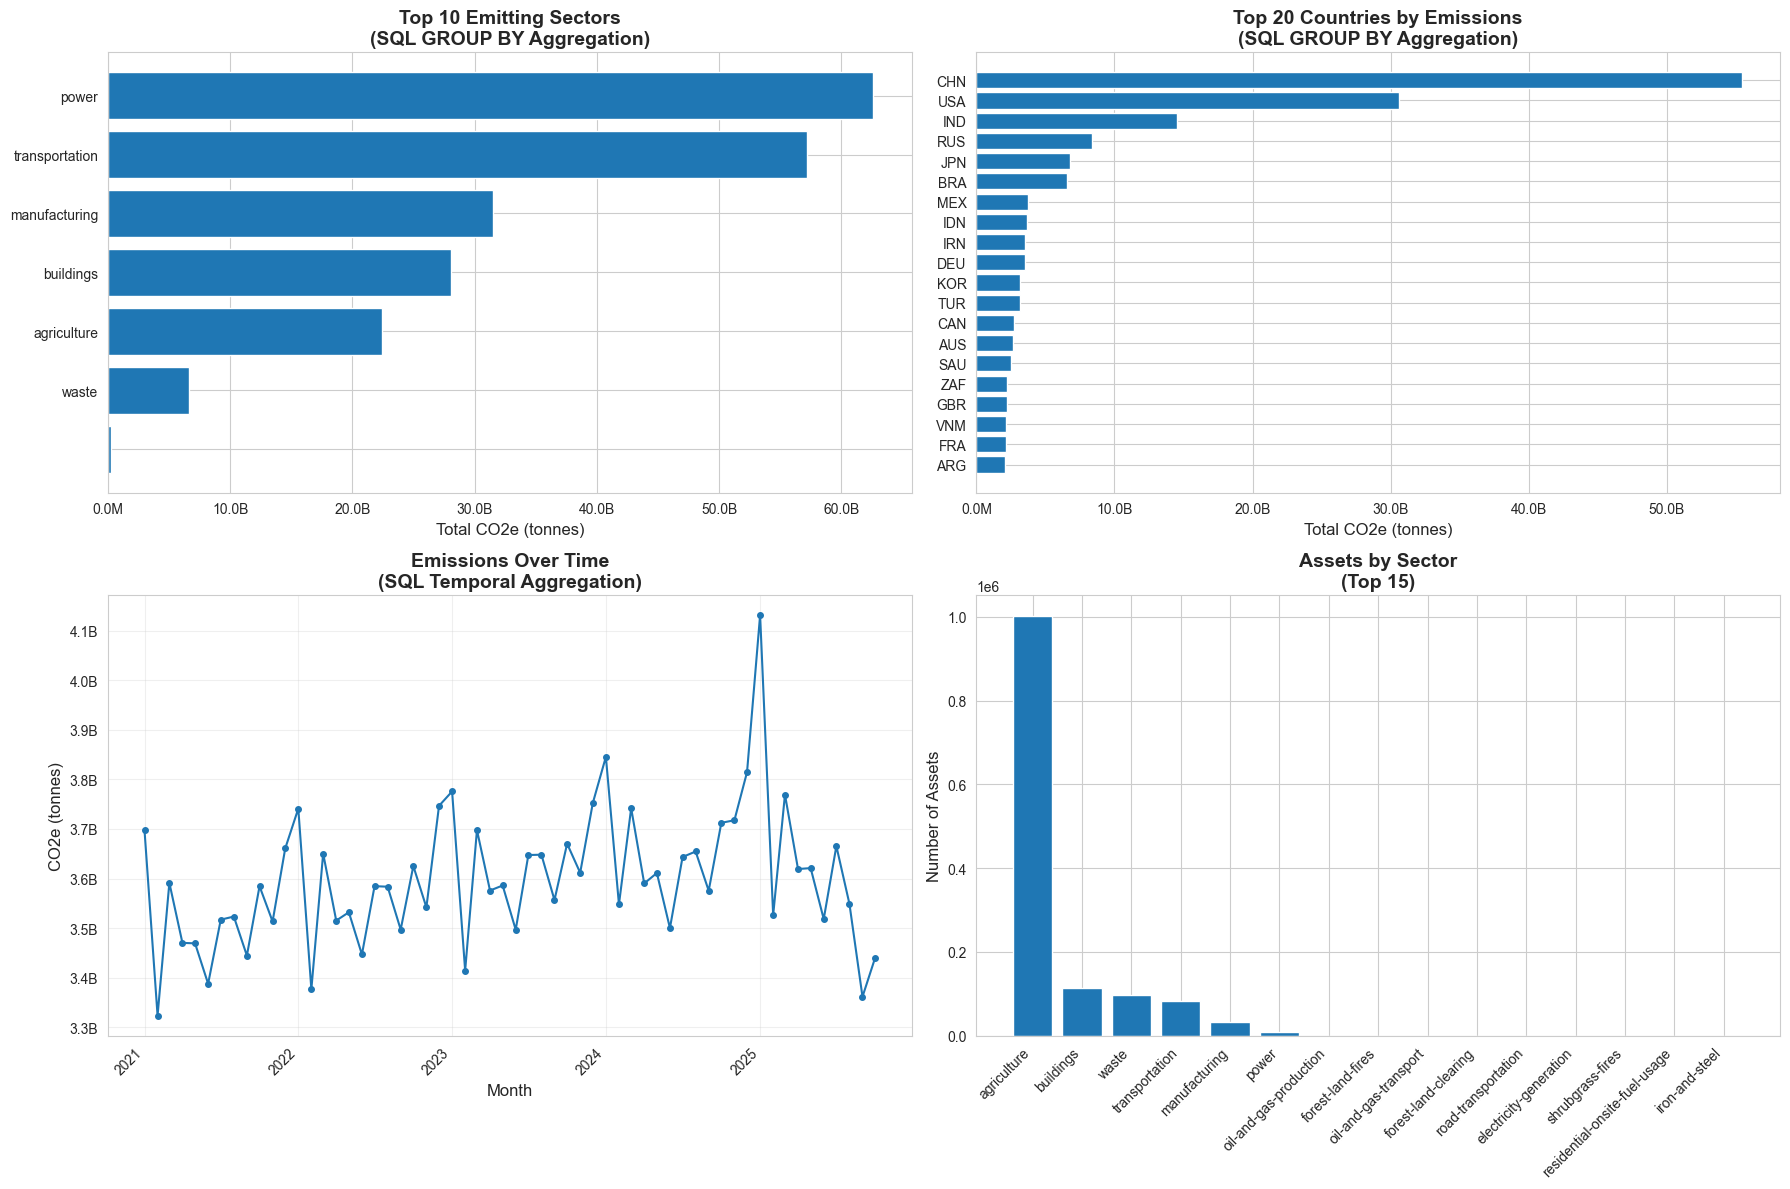


✅ Visualizations created


In [13]:
print("="*80)
print("📊 VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Top 10 Sectors by Emissions
if report_data.get('sector_totals'):
    df_sectors = pd.DataFrame(report_data['sector_totals']).sort_values('total_co2e', ascending=False)
    top_10_sectors = df_sectors.head(10)
    
    axes[0, 0].barh(range(len(top_10_sectors)), top_10_sectors['total_co2e'].values)
    axes[0, 0].set_yticks(range(len(top_10_sectors)))
    axes[0, 0].set_yticklabels(top_10_sectors['sector_name'].values)
    axes[0, 0].set_xlabel('Total CO2e (tonnes)', fontsize=12)
    axes[0, 0].set_title('Top 10 Emitting Sectors\n(SQL GROUP BY Aggregation)', fontsize=14, fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.1f}M'))
else:
    axes[0, 0].text(0.5, 0.5, 'Sector data\nnot available', ha='center', va='center')
    axes[0, 0].set_title('Top 10 Emitting Sectors')

# 2. Top 20 Countries by Emissions
if report_data.get('country_totals'):
    df_countries = pd.DataFrame(report_data['country_totals'])
    # country_name is already included in the API response
    top_20_countries = df_countries.sort_values('total_co2e', ascending=False).head(20)
    
    axes[0, 1].barh(range(len(top_20_countries)), top_20_countries['total_co2e'].values)
    axes[0, 1].set_yticks(range(len(top_20_countries)))
    axes[0, 1].set_yticklabels(top_20_countries['country_name'].values)
    axes[0, 1].set_xlabel('Total CO2e (tonnes)', fontsize=12)
    axes[0, 1].set_title('Top 20 Countries by Emissions\n(SQL GROUP BY Aggregation)', fontsize=14, fontweight='bold')
    axes[0, 1].invert_yaxis()
    axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.1f}M'))
else:
    axes[0, 1].text(0.5, 0.5, 'Country data\nnot available', ha='center', va='center')
    axes[0, 1].set_title('Top 20 Countries by Emissions')

# 3. Temporal Distribution
if report_data.get('temporal_aggregations'):
    df_temporal = pd.DataFrame(report_data['temporal_aggregations'])
    if 'time_period' in df_temporal.columns and 'total_co2e' in df_temporal.columns:
        df_temporal['time_period'] = pd.to_datetime(df_temporal['time_period'])
        df_temporal = df_temporal.sort_values('time_period')
        
        axes[1, 0].plot(df_temporal['time_period'], df_temporal['total_co2e'], marker='o', markersize=4)
        axes[1, 0].set_xlabel('Month', fontsize=12)
        axes[1, 0].set_ylabel('CO2e (tonnes)', fontsize=12)
        axes[1, 0].set_title('Emissions Over Time\n(SQL Temporal Aggregation)', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.1f}M'))
        plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        axes[1, 0].text(0.5, 0.5, 'Temporal data\nnot available', ha='center', va='center')
        axes[1, 0].set_title('Emissions Over Time')
else:
    axes[1, 0].text(0.5, 0.5, 'Temporal data\nnot available', ha='center', va='center')
    axes[1, 0].set_title('Emissions Over Time')

# 4. Assets by Sector
if report_data.get('assets', {}).get('by_sector'):
    sector_assets = report_data['assets']['by_sector']
    df_assets = pd.DataFrame([
        {'sector_name': k, 'asset_count': v}
        for k, v in sector_assets.items()
    ]).sort_values('asset_count', ascending=False).head(15)
    
    axes[1, 1].bar(range(len(df_assets)), df_assets['asset_count'].values)
    axes[1, 1].set_xticks(range(len(df_assets)))
    axes[1, 1].set_xticklabels(df_assets['sector_name'].values, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Number of Assets', fontsize=12)
    axes[1, 1].set_title('Assets by Sector\n(Top 15)', fontsize=14, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'Asset data\nnot available', ha='center', va='center')
    axes[1, 1].set_title('Assets by Sector')

plt.tight_layout()
plt.show()

print("\n✅ Visualizations created")


## Generate Report

Generate comprehensive markdown report from `report_data` dictionary.


In [14]:
# Generate comprehensive markdown report
import os
from datetime import datetime
from pathlib import Path

# Create notebook_reports directory if it doesn't exist
project_root = Path('/Users/willardmechem/Projects/repos/Jana')
reports_dir = project_root / 'notebook_reports'
reports_dir.mkdir(exist_ok=True)

# Generate report filename with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
report_filename = f'climatetrace_data_summary_v2_{timestamp}.md'
report_path = reports_dir / report_filename

print(f"Generating comprehensive Climate TRACE data report...")
print(f"Report will be saved to: {report_path}")

# Start building the markdown report
report_lines = []
report_lines.append("# Climate TRACE Data Summary Report v2")
report_lines.append("")
report_lines.append(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")
report_lines.append("**Note:** This report uses 100% accurate SQL aggregations (SUM, GROUP BY) for all totals.")
report_lines.append("")
report_lines.append("---")
report_lines.append("")

# 1. Platform Summary
report_lines.append("## 1. Platform Summary")
report_lines.append("")
ps = report_data.get('platform_summary', {})
report_lines.append(f"- **Total Emission Records:** {ps.get('total_emission_records', 0):,}")
report_lines.append(f"- **Total Assets:** {ps.get('total_assets', 0):,}")
report_lines.append(f"- **Total Sectors:** {ps.get('total_sectors', 0)}")
report_lines.append(f"- **Total Countries:** {ps.get('total_countries', 0)}")
report_lines.append("")

# 2. Emissions Totals
report_lines.append("## 2. Emissions Totals (SQL SUM Aggregation)")
report_lines.append("")
et = report_data.get('emissions_totals', {})
report_lines.append(f"- **Total CO2e:** {et.get('total_co2e', 0):,.2f} tonnes")
report_lines.append(f"- **Total CO2:** {et.get('total_co2', 0):,.2f} tonnes")
report_lines.append(f"- **Total CH4:** {et.get('total_ch4', 0):,.2f} tonnes")
report_lines.append(f"- **Total N2O:** {et.get('total_n2o', 0):,.2f} tonnes")
report_lines.append(f"- **Record Count:** {et.get('record_count', 0):,}")
report_lines.append(f"- **Average CO2e per Record:** {et.get('avg_co2e', 0):,.2f} tonnes")
report_lines.append("")

# 3. Date Range
report_lines.append("## 3. Date Range Coverage")
report_lines.append("")
dr = report_data.get('date_range', {})
if dr.get('earliest_date') and dr.get('latest_date'):
    report_lines.append(f"- **Earliest Date:** {dr.get('earliest_date')}")
    report_lines.append(f"- **Latest Date:** {dr.get('latest_date')}")
    if 'span_days' in dr:
        report_lines.append(f"- **Span:** {dr.get('span_days', 0):,} days (~{dr.get('span_years', 0):.1f} years)")
else:
    report_lines.append("- *Date range data not available*")
report_lines.append("")

# 4. Sector Totals
report_lines.append("## 4. Sector Totals (SQL GROUP BY Aggregation)")
report_lines.append("")
st = report_data.get('sector_totals', [])
if st:
    report_lines.append(f"**Total Sectors with Emissions:** {len(st)}")
    report_lines.append("")
    report_lines.append("### Top 10 Emitting Sectors:")
    report_lines.append("")
    report_lines.append("| Rank | Sector | Total CO2e (tonnes) | Emission Records | Unique Assets |")
    report_lines.append("|------|--------|-------------------|------------------|---------------|")
    df_sectors = pd.DataFrame(st).sort_values('total_co2e', ascending=False)
    for idx, (_, row) in enumerate(df_sectors.head(10).iterrows(), 1):
        report_lines.append(f"| {idx} | {row.get('sector_name', 'Unknown')} | {row.get('total_co2e', 0):,.0f} | {row.get('record_count', 0):,} | {row.get('unique_assets', 0):,} |")
else:
    report_lines.append("- *Sector totals data not available*")
report_lines.append("")

# 5. Country Totals
report_lines.append("## 5. Country Totals (SQL GROUP BY Aggregation)")
report_lines.append("")
ct = report_data.get('country_totals', [])
if ct:
    report_lines.append(f"**Total Countries with Emissions:** {len(ct)}")
    report_lines.append("")
    report_lines.append("### Top 20 Countries by Total CO2e Emissions:")
    report_lines.append("")
    report_lines.append("| Rank | Country | ISO3 | Total CO2e (tonnes) | Emission Records | Unique Assets |")
    report_lines.append("|------|---------|------|-------------------|------------------|---------------|")
    df_countries = pd.DataFrame(ct)
    # country_name is already included in the API response
    df_countries = df_countries.sort_values('total_co2e', ascending=False)
    for idx, (_, row) in enumerate(df_countries.head(20).iterrows(), 1):
        report_lines.append(f"| {idx} | {row.get('country_name', 'Unknown')} | {row.get('country_iso3', 'N/A')} | {row.get('total_co2e', 0):,.0f} | {row.get('record_count', 0):,} | {row.get('unique_assets', 0):,} |")
else:
    report_lines.append("- *Country totals data not available*")
report_lines.append("")

# 6. Assets Distribution
report_lines.append("## 6. Assets Distribution by Sector")
report_lines.append("")
assets = report_data.get('assets', {})
if assets.get('total'):
    report_lines.append(f"- **Total Assets:** {assets.get('total', 0):,}")
    report_lines.append("")
    if assets.get('by_sector'):
        report_lines.append("### Assets by Sector (Top 15):")
        report_lines.append("")
        report_lines.append("| Sector | Asset Count |")
        report_lines.append("|--------|-------------|")
        sector_assets = assets['by_sector']
        sorted_sectors = sorted(sector_assets.items(), key=lambda x: x[1], reverse=True)[:15]
        for sector_name, count in sorted_sectors:
            report_lines.append(f"| {sector_name} | {count:,} |")
    else:
        report_lines.append("- *Asset distribution data not available*")
else:
    report_lines.append("- *Asset data not available*")
report_lines.append("")

# 7. Temporal Distribution
report_lines.append("## 7. Temporal Distribution (Monthly Aggregations)")
report_lines.append("")
ta = report_data.get('temporal_aggregations', [])
if ta:
    df_temporal = pd.DataFrame(ta)
    if 'time_period' in df_temporal.columns:
        df_temporal['time_period'] = pd.to_datetime(df_temporal['time_period'])
        report_lines.append(f"- **Total Monthly Periods:** {len(df_temporal)}")
        report_lines.append(f"- **Date Range:** {df_temporal['time_period'].min()} to {df_temporal['time_period'].max()}")
        if 'total_co2e' in df_temporal.columns:
            total_co2e = df_temporal['total_co2e'].sum()
            avg_co2e = df_temporal['total_co2e'].mean()
            report_lines.append(f"- **Total CO2e (all periods):** {total_co2e:,.0f} tonnes")
            report_lines.append(f"- **Average Monthly CO2e:** {avg_co2e:,.0f} tonnes")
else:
    report_lines.append("- *Temporal aggregation data not available*")
report_lines.append("")

# 8. Data Quality
report_lines.append("## 8. Data Quality Notes")
report_lines.append("")
dq = report_data.get('data_quality', {})
if dq:
    report_lines.append(f"**Sample Size:** {dq.get('sample_size', 0):,} records")
    report_lines.append("")
    
    if dq.get('gas_field_distribution'):
        report_lines.append("### Gas Field Distribution:")
        report_lines.append("")
        for gas, count in dq['gas_field_distribution'].items():
            pct = (count / dq['sample_size']) * 100 if dq['sample_size'] > 0 else 0
            report_lines.append(f"- **{gas.upper()}:** {count:,} ({pct:.1f}%)")
        report_lines.append("")
    
    if dq.get('gas_column_completeness'):
        report_lines.append("### Gas Column Completeness:")
        report_lines.append("")
        for col, metrics in dq['gas_column_completeness'].items():
            report_lines.append(f"- **{col}:** {metrics['non_null_count']:,}/{dq['sample_size']:,} ({metrics['non_null_percentage']:.1f}%)")
        report_lines.append("")
    
    if 'co2e' in dq.get('gas_field_distribution', {}):
        co2e_pct = (dq['gas_field_distribution']['co2e'] / dq['sample_size']) * 100 if dq['sample_size'] > 0 else 0
        if co2e_pct > 95:
            report_lines.append("**Note:** Almost all emissions are stored as 'co2e' (CO2 equivalent).")
            report_lines.append("This is expected - Climate TRACE primarily provides CO2e values.")
            report_lines.append("")
else:
    report_lines.append("- *Data quality analysis not available*")
report_lines.append("")

# Summary Statistics
report_lines.append("## Summary Statistics")
report_lines.append("")
report_lines.append(f"- **Total Emissions (CO2e):** {et.get('total_co2e', 0):,.0f} tonnes")
report_lines.append(f"- **Total Emission Records:** {ps.get('total_emission_records', 0):,}")
report_lines.append(f"- **Total Assets:** {ps.get('total_assets', 0):,}")
report_lines.append(f"- **Total Sectors:** {ps.get('total_sectors', 0)}")
report_lines.append(f"- **Total Countries:** {ps.get('total_countries', 0)}")
report_lines.append("")

# Footer
report_lines.append("---")
report_lines.append("")
report_lines.append(f"*Report generated by Climate TRACE Data Summary Notebook v2*")
report_lines.append(f"*Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*")
report_lines.append("")
report_lines.append("**Methodology:**")
report_lines.append("- All totals calculated using SQL SUM aggregations (100% accurate)")
report_lines.append("- Sector and country totals use SQL GROUP BY aggregations")
report_lines.append("- Temporal aggregations use SQL GROUP BY with monthly resolution")
report_lines.append("- All operations performed at database level for optimal performance")

# Write the report to file
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print(f"✅ Report generated successfully!")
print(f"   Location: {report_path}")
print(f"   Size: {len(report_lines)} lines")
print(f"\n📄 Report preview (first 30 lines):")
print("\n".join(report_lines[:30]))


Generating comprehensive Climate TRACE data report...
Report will be saved to: /Users/willardmechem/Projects/repos/Jana/notebook_reports/climatetrace_data_summary_v2_20260103_024646.md
✅ Report generated successfully!
   Location: /Users/willardmechem/Projects/repos/Jana/notebook_reports/climatetrace_data_summary_v2_20260103_024646.md
   Size: 143 lines

📄 Report preview (first 30 lines):
# Climate TRACE Data Summary Report v2

**Generated:** 2026-01-03 02:46:46

**Note:** This report uses 100% accurate SQL aggregations (SUM, GROUP BY) for all totals.

---

## 1. Platform Summary

- **Total Emission Records:** 53,422,192
- **Total Assets:** 1,337,615
- **Total Sectors:** 26
- **Total Countries:** 251

## 2. Emissions Totals (SQL SUM Aggregation)

- **Total CO2e:** 208,610,632,675.53 tonnes
- **Total CO2:** 0.00 tonnes
- **Total CH4:** 0.00 tonnes
- **Total N2O:** 0.00 tonnes
- **Record Count:** 53,422,192
- **Average CO2e per Record:** 3,904.94 tonnes

## 3. Date Range Coverage

- **Ea